In [1]:
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import kaleido

In [2]:
# set chart style preferences
plt.style.use('default')
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Verdana'

### data loading

In [3]:
df_arrests: pd.DataFrame = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/arrests_cleaned.parquet')
df_detainers: pd.DataFrame  = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/detainers_cleaned.parquet')
df_detentions: pd.DataFrame = pd.read_parquet('/Users/leahmayotte/Documents/education/umass/capstone/2_data/cleaned/detention_stays_cleaned.parquet')

print(f"    - {len(df_arrests):,} arrests")
print(f"    - {len(df_detainers):,} detainers")
print(f"    - {len(df_detentions):,} detentions")

    - 362,202 arrests
    - 329,483 detainers
    - 671,750 detentions


### trends

#### time analysis

In [4]:
# count arrests per year
arrests_per_year = df_arrests.groupby('apprehension_year').size()
print(arrests_per_year)
print()
# count detainers per year
detainers_per_year = df_detainers.groupby('detainer_year').size()
print(detainers_per_year)
print()
# count detention stays per year
detentions_per_year = df_detentions.groupby('stay_year').size()
print(detentions_per_year)
print()

apprehension_year
2023     38590
2024    107878
2025    215734
dtype: int64

detainer_year
2023     35041
2024    131235
2025    163207
dtype: int64

stay_year
2004         1
2011         1
2014         5
2015         1
2016         1
2017         3
2018         7
2019        24
2020        37
2021        92
2022       983
2023    119338
2024    279903
2025    271354
dtype: int64



In [5]:
# the output for detention stays per year had entries going back to 2004
# adjusting to only include entries from 2023 and later
print(detentions_per_year.index)

detentions_per_year = df_detentions.groupby('stay_year').size()
detentions_per_year = detentions_per_year[detentions_per_year.index >= 2023]
print(detentions_per_year)

Index([2004, 2011, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024, 2025],
      dtype='int32', name='stay_year')
stay_year
2023    119338
2024    279903
2025    271354
dtype: int64


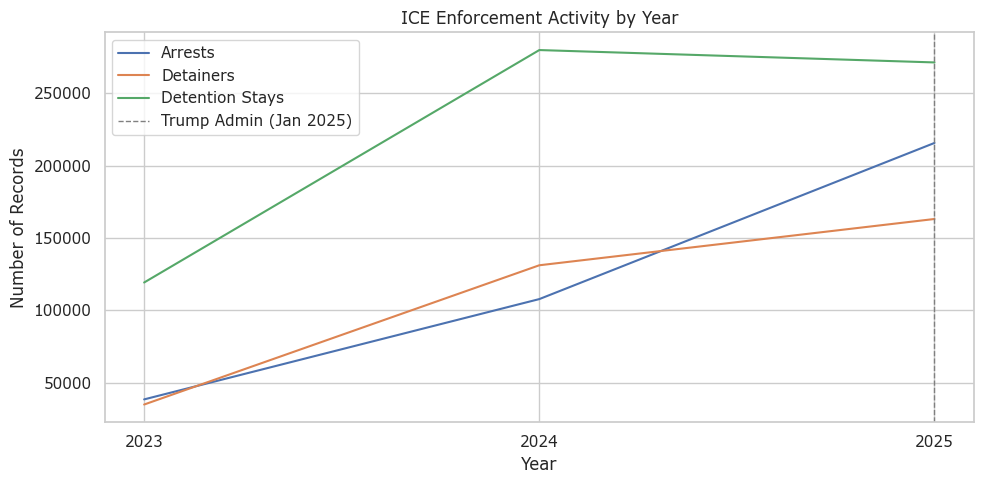

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    x=arrests_per_year.index,
    y=arrests_per_year.values,
    label='Arrests',
    ax=ax
)

sns.lineplot(
    x=detainers_per_year.index,
    y=detainers_per_year.values,
    label='Detainers',
    ax=ax
)

sns.lineplot(
    x=detentions_per_year.index,
    y=detentions_per_year.values,
    label='Detention Stays',
    ax=ax
)
# create administration change reference line
ax.axvline(x=2025, color='gray', linestyle='--', linewidth=1, label='Trump Admin (Jan 2025)')

ax.set_title('ICE Enforcement Activity by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Records')

ax.legend()
ax.set_xticks([2023, 2024, 2025])


plt.tight_layout()
plt.show()

In [7]:
# the previous chart is misleading - reworking for monthly granularity

arrests_per_month = df_arrests.groupby(df_arrests['apprehension_date'].dt.to_period('M')).size().reset_index(name='count')
detainers_per_month = df_detainers.groupby(df_detainers['detainer_prepare_date'].dt.to_period('M')).size().reset_index(name='count')
detentions_per_month = df_detentions.groupby(df_detentions['stay_book_in_date_time'].dt.to_period('M')).size().reset_index(name='count')

# reapply the filter for any detention records before 2023
detentions_per_month = detentions_per_month[detentions_per_month['stay_book_in_date_time'] >= '2023-01']

# convert back to datetime
arrests_per_month['date'] = arrests_per_month['apprehension_date'].dt.to_timestamp()
detainers_per_month['date'] = detainers_per_month['detainer_prepare_date'].dt.to_timestamp()
detentions_per_month['date'] = detentions_per_month['stay_book_in_date_time'].dt.to_timestamp()

print(arrests_per_month.head())


  apprehension_date  count       date
0           2023-09  10316 2023-09-01
1           2023-10   9831 2023-10-01
2           2023-11   8747 2023-11-01
3           2023-12   9696 2023-12-01
4           2024-01   8341 2024-01-01


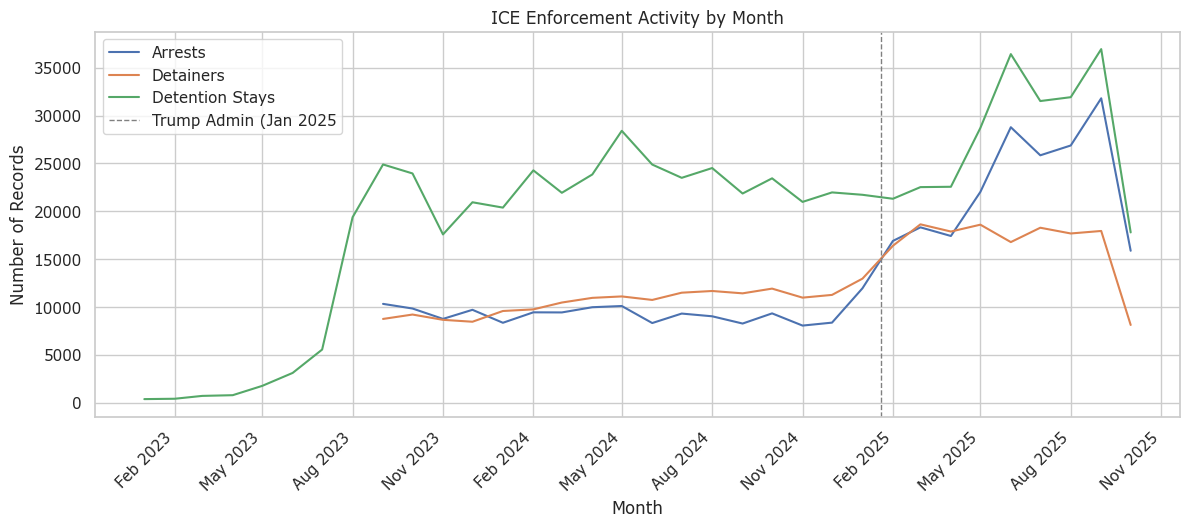

In [8]:
fig, ax = plt.subplots(figsize=(14,5))

sns.lineplot(
    data=arrests_per_month,
    x='date',
    y='count',
    label='Arrests',
    ax=ax
)

sns.lineplot(
    data=detainers_per_month,
    x='date',
    y='count',
    label='Detainers',
    ax=ax
)

sns.lineplot(
    data=detentions_per_month,
    x='date',
    y='count',
    label='Detention Stays'
)

# create administration change reference line
ax.axvline(x=pd.Timestamp('2025-01-20'), color='gray', linestyle='--', linewidth=1, label='Trump Admin (Jan 2025')

# Format x-axis as readable month/year labels
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

ax.set_title('ICE Enforcement Activity by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Records')
ax.legend()

plt.tight_layout
plt.show()

In [9]:
# chart identified a discrepancy in the date range for the datasets
# running code to determine each table's date range

print(f'Arrests date range:     {df_arrests['apprehension_date'].min()} -> {df_arrests['apprehension_date'].max()}')
print(f'Detainers date range:    {df_detainers['detainer_prepare_date'].min()} -> {df_detainers['detainer_prepare_date'].max()}')
print(f'Detentions date range:    {df_detentions['stay_book_in_date_time'].min()} -> {df_detentions['stay_book_in_date_time'].max()}')
# data needs to be trimmed to maintain consistency in analysis

Arrests date range:     2023-09-01 00:00:00 -> 2025-10-16 00:00:00
Detainers date range:    2023-09-01 00:00:00 -> 2025-10-15 00:00:00
Detentions date range:    2004-12-05 22:30:00 -> 2025-10-16 00:28:00


In [10]:
# re-defining monthly data to include exactly 2 years of data

arrests_per_month = arrests_per_month[arrests_per_month['date'] <= '2025-09-30']
detainers_per_month = detainers_per_month[detainers_per_month['date'] <= '2025-09-30']
detentions_per_month = detentions_per_month[(detentions_per_month['date'] >= '2023-09-01') & (detentions_per_month['date'] <= '2025-09-30')]

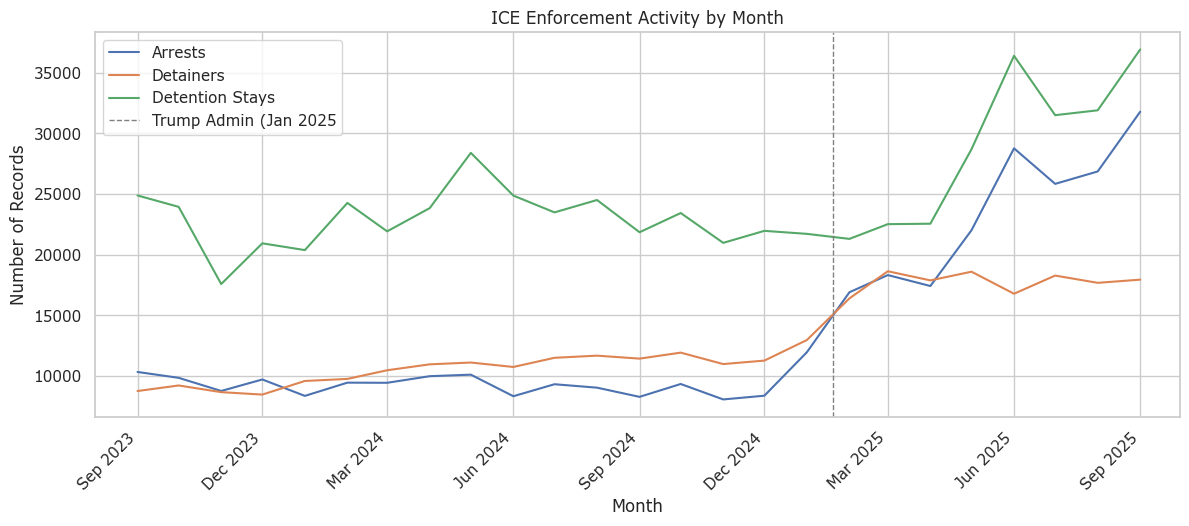

In [11]:
# re-running chart with updated date range

fig, ax = plt.subplots(figsize=(14,5))

sns.lineplot(
    data=arrests_per_month,
    x='date',
    y='count',
    label='Arrests',
    ax=ax
)

sns.lineplot(
    data=detainers_per_month,
    x='date',
    y='count',
    label='Detainers',
    ax=ax
)

sns.lineplot(
    data=detentions_per_month,
    x='date',
    y='count',
    label='Detention Stays'
)

# create administration change reference line
ax.axvline(x=pd.Timestamp('2025-01-20'), color='gray', linestyle='--', linewidth=1, label='Trump Admin (Jan 2025')

# Format x-axis as readable month/year labels
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9, 12, 3, 6]))
plt.xticks(rotation=45, ha='right')
# adjusting month labels to reflect September data with a slight buffer
ax.set_xlim(pd.Timestamp('2023-08-01'), pd.Timestamp('2025-09-30'))

ax.set_title('ICE Enforcement Activity by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Records')
ax.legend()

plt.tight_layout
plt.show()

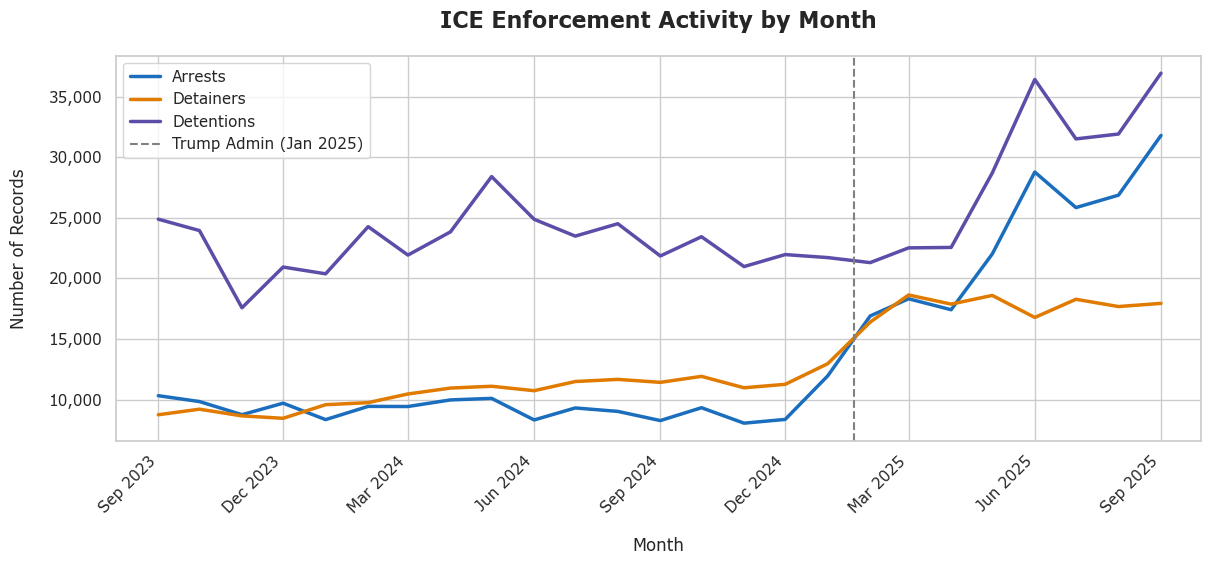

In [12]:
# adjusting formatting to make the chart 'prettier' and easier to read
# (adjusting colors to avoid red and green, thicker lines, adjusted title placement, style, and padding
# added global font formatting to top of the file

fig, ax = plt.subplots(figsize=(14,5))

sns.lineplot(
    data=arrests_per_month,
    x='date',
    y='count',
    label='Arrests',
    color='#1A6EBD', # adjust color
    linewidth=2.5, # adjust line width
    ax=ax
)

sns.lineplot(
    data=detainers_per_month,
    x='date',
    y='count',
    label='Detainers',
    color='#E07B00',
    linewidth=2.5,
    ax=ax
)

sns.lineplot(
    data=detentions_per_month,
    x='date',
    y='count',
    label='Detentions',
    color='#5B4EA8',
    linewidth=2.5,
    ax=ax
)

# reference line at inaugeration day
ax.axvline(x=pd.Timestamp('2025-01-20'), color='gray', linestyle='--', linewidth=1.5, label='Trump Admin (Jan 2025)')

# formatting x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[9, 12, 3, 6])) # manually display starting with Sept.
plt.xticks(rotation=45, ha='right')
ax.set_xlim(pd.Timestamp('2023-08-01'), pd.Timestamp('2025-09-30'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) # add comma to y-axis numbers

ax.set_title('ICE Enforcement Activity by Month', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', labelpad=15)
ax.set_ylabel('Number of Records', labelpad=15)
ax.legend()

plt.tight_layout
plt.show()

In [13]:
# setting inauguration day for reference
transition_date = pd.Timestamp('2025-01-20')

# splitting datasets into pre and post presidential transition
arrests_pre = arrests_per_month[arrests_per_month['date'] < transition_date]
arrests_post = arrests_per_month[arrests_per_month['date'] > transition_date]

detainers_pre = detainers_per_month[detainers_per_month['date'] < transition_date]
detainers_post = detainers_per_month[detainers_per_month['date'] > transition_date]

detentions_pre = detentions_per_month[detentions_per_month['date'] < transition_date]
detentions_post = detentions_per_month[detentions_per_month['date'] > transition_date]

# create a new summary table
summary = pd.DataFrame({
    'Metric' : ['Arrests', 'Detainers', 'Detentions'],
    'Average Monthly (Pre-Transition)' : [
        arrests_pre['count'].mean().round(0),
        detainers_pre['count'].mean().round(0),
        detentions_pre['count'].mean().round(0)
    ],
    'Average Monthly (Post-Transition)' : [
        arrests_post['count'].mean().round(0),
        detainers_post['count'].mean().round(0),
        detentions_post['count'].mean().round(0)
    ]
})

# calculation percentages change between pre/post
# (post - pre) / pre * 100
summary['Percentage Change'] = ((summary['Average Monthly (Post-Transition)'] - summary['Average Monthly (Pre-Transition)']) / summary['Average Monthly (Pre-Transition)'] * 100).round(1)

print(summary.to_string(index=False))

    Metric  Average Monthly (Pre-Transition)  Average Monthly (Post-Transition)  Percentage Change
   Arrests                            9319.0                            23490.0              152.1
 Detainers                           10543.0                            17768.0               68.5
Detentions                           22880.0                            28982.0               26.7


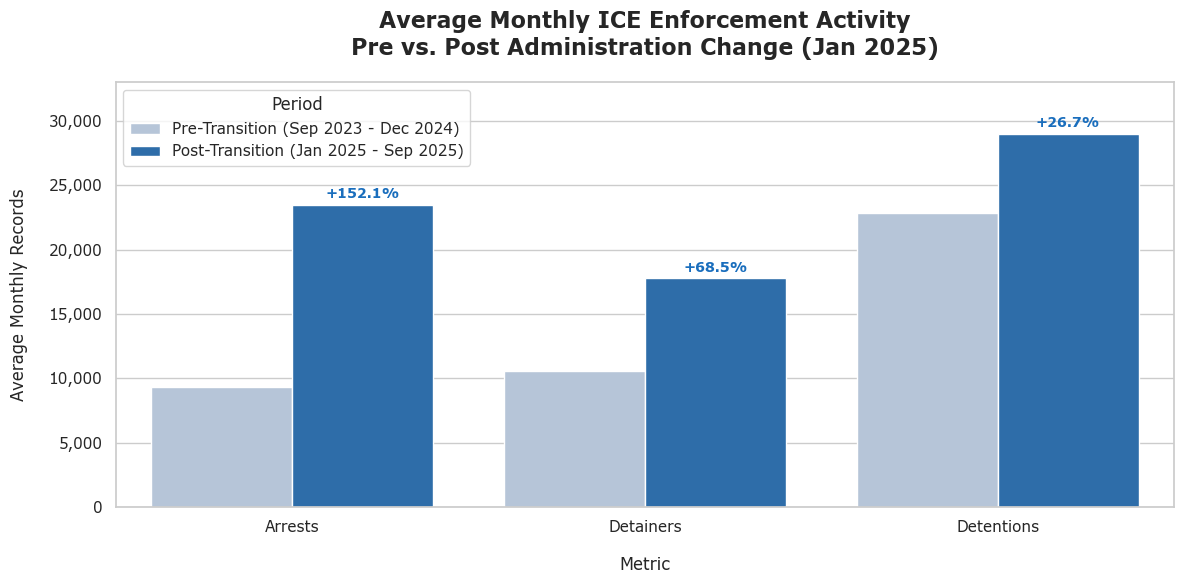

In [14]:
# create a bar chart to visualize this finding

# reshape to long format
summary_long = summary.melt(
    id_vars = 'Metric',
    value_vars = ['Average Monthly (Pre-Transition)', 'Average Monthly (Post-Transition)'],
    var_name = 'Period',
    value_name = 'Average Monthly Records'
)

# rename period labels for cleaner legend
summary_long['Period'] = summary_long['Period'].map({
    'Average Monthly (Pre-Transition)' : 'Pre-Transition (Sep 2023 - Dec 2024)',
    'Average Monthly (Post-Transition)' : 'Post-Transition (Jan 2025 - Sep 2025)'
})


fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=summary_long,
    x='Metric',
    y='Average Monthly Records',
    hue='Period',
    palette=['#B0C4DE', '#1A6EBD'],
    ax=ax
)

# annotate percentage change above post-transition bars
x_positions = [0.2, 1.2, 2.2] # approx. center of each post-transition bar
heights = summary['Average Monthly (Post-Transition)'].tolist()
pct_labels = summary['Percentage Change'].to_list()
pct_changes = summary['Percentage Change']

# used documentation to better understand zip() function https://docs.python.org/3/library/functions.html#zip
for x, height, pct in zip(x_positions, heights, pct_labels): # ties the three lists together
    ax.text(x, height + 300, f'+{pct}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#1A6EBD')

ax.set_title('Average Monthly ICE Enforcement Activity\nPre vs. Post Administration Change (Jan 2025)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Metric', labelpad=15)
ax.set_ylabel('Average Monthly Records', labelpad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) # add comma to y-axis numbers
ax.set_ylim(0, 33000) # extend y-axis limit to accommodate percentage increase in detentions

plt.tight_layout()
plt.show()

#### geographic analysis

In [15]:
# top 10 citizenship countries for each dataset

arrests_top_countries = (df_arrests['citizenship_country'].value_counts().head(10))
detainers_top_countries = (df_detainers['citizenship_country'].value_counts().head(10))
detentions_top_countries = (df_detentions['citizenship_country'].value_counts().head(10))

print('ARRESTS')
print('----------')
print(arrests_top_countries)
print()
print('DETAINERS')
print('----------')
print(detainers_top_countries)
print()
print('DETENTIONS')
print('----------')
print(detentions_top_countries)

ARRESTS
----------
citizenship_country
MEXICO                137406
GUATEMALA              46926
HONDURAS               40294
VENEZUELA              21349
NICARAGUA              17796
EL SALVADOR            16701
COLOMBIA               12878
ECUADOR                12045
CUBA                    8827
DOMINICAN REPUBLIC      6144
Name: count, dtype: int64

DETAINERS
----------
citizenship_country
MEXICO                137554
GUATEMALA              38162
HONDURAS               36691
EL SALVADOR            17530
VENEZUELA              17475
COLOMBIA               11192
NICARAGUA               9701
CUBA                    7687
ECUADOR                 7582
DOMINICAN REPUBLIC      5780
Name: count, dtype: int64

DETENTIONS
----------
citizenship_country
MEXICO                195623
GUATEMALA              85907
HONDURAS               69316
VENEZUELA              46124
ECUADOR                38889
COLOMBIA               37542
EL SALVADOR            28382
NICARAGUA              20025
INDIA       

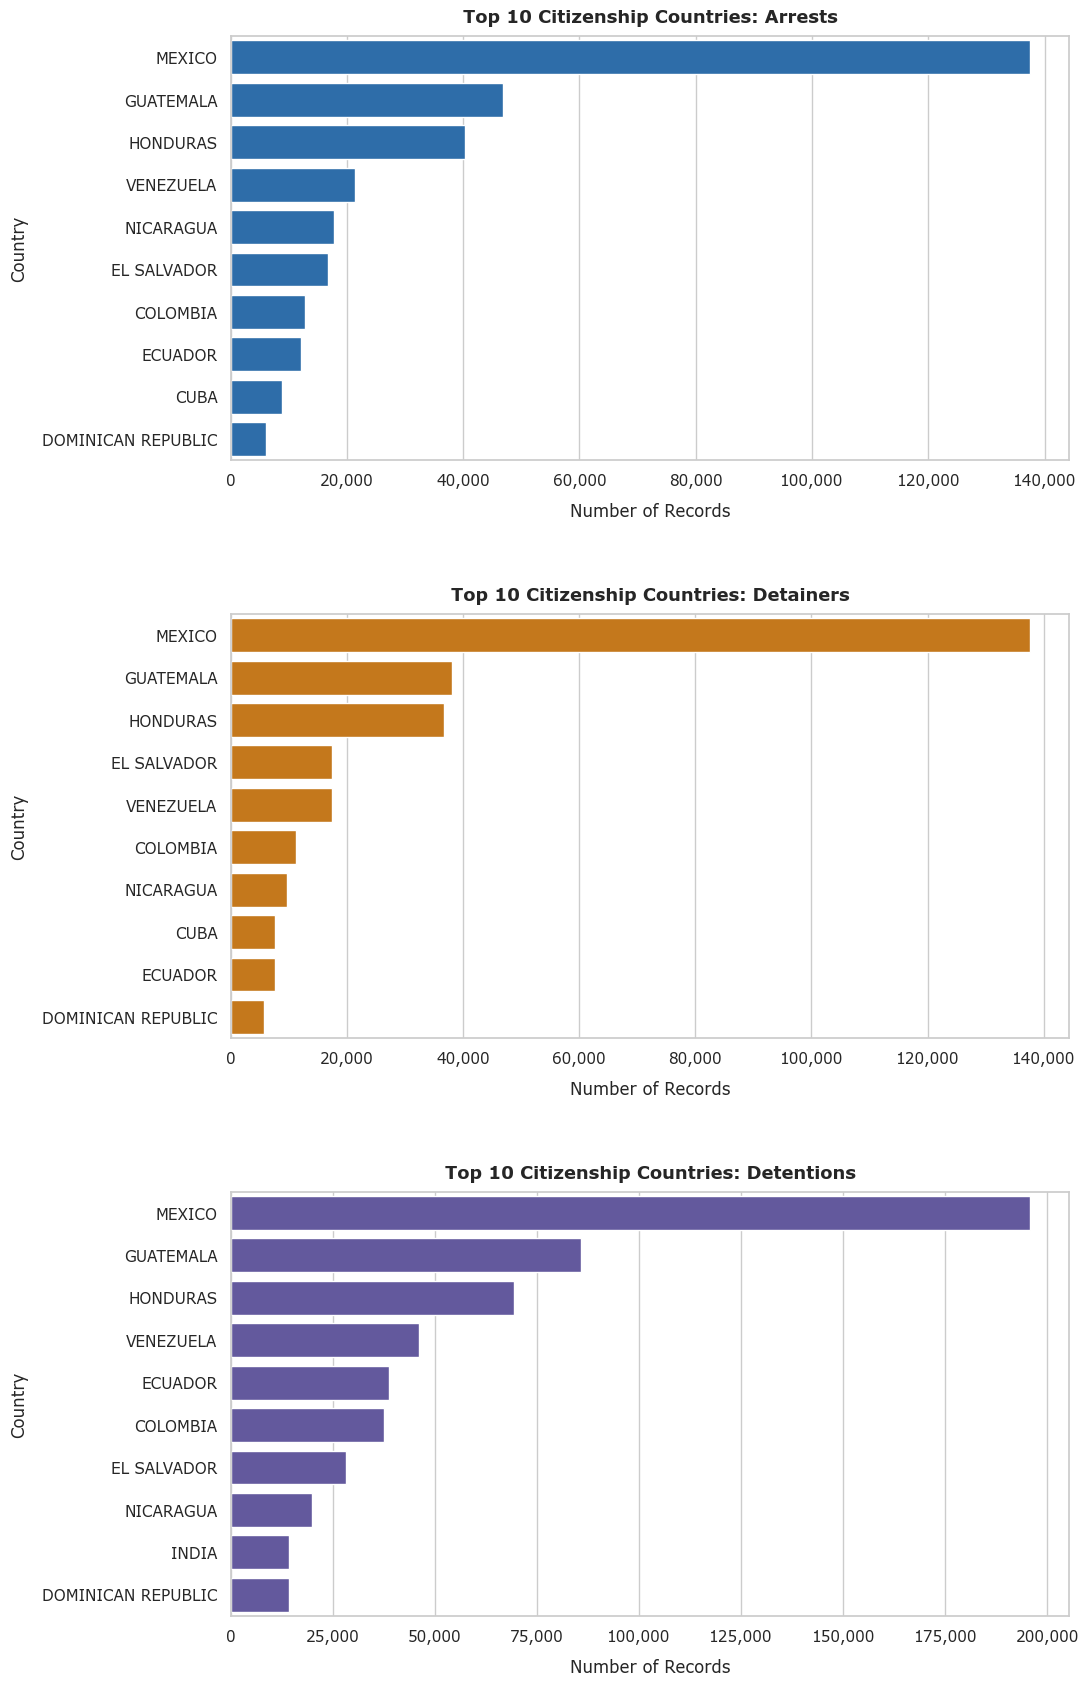

In [16]:
# creating a horizontal bar chart for each table to visualize this information

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

# Arrests
sns.barplot(
    x=arrests_top_countries.values,
    y=arrests_top_countries.index,
    ax=ax1,
    color='#1A6EBD'
)

ax1.set_title('Top 10 Citizenship Countries: Arrests', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Number of Records', labelpad=10)
ax1.set_ylabel('Country', labelpad=10)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Detainers
sns.barplot(
    x=detainers_top_countries.values,
    y=detainers_top_countries.index,
    ax=ax2,
    color='#E07B00'
)

ax2.set_title('Top 10 Citizenship Countries: Detainers', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Number of Records', labelpad=10)
ax2.set_ylabel('Country', labelpad=10)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Detentions
sns.barplot(
    x=detentions_top_countries.values,
    y=detentions_top_countries.index,
    ax=ax3,
    color='#5B4EA8'
)

ax3.set_title('Top 10 Citizenship Countries: Detentions', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('Number of Records', labelpad=10)
ax3.set_ylabel('Country', labelpad=10)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout(pad=4.0)
plt.show()

In [17]:
# understanding volume of records by state
# try to identify state column in the detentions table
print(df_detentions.columns.tolist())
print(df_detentions['detention_facility_code_first'].value_counts().head(20))
# unable to find usable column - will continue analysis on arrests and detainers only

['stay_ID', 'n_stints', 'stay_book_in_date_time', 'stay_book_out_date_time', 'detention_release_reason', 'stay_release_reason', 'gender', 'marital_status', 'birth_year', 'ethnicity', 'entry_status', 'felon', 'bond_posted_date', 'bond_posted_amount', 'case_status', 'case_category', 'final_order_yes_no', 'final_order_date', 'case_threat_level', 'book_in_criminality', 'final_charge', 'departed_date', 'departure_country', 'initial_bond_set_amount', 'citizenship_country', 'final_program', 'most_serious_conviction_code', 'msc_charge', 'unique_identifier', 'n_stays', 'detention_facility_first', 'detention_facility_code_first', 'book_out_date_time_first', 'detention_facility_longest', 'detention_facility_code_longest', 'book_in_date_time_longest', 'book_out_date_time_longest', 'detention_facility_last', 'detention_facility_code_last', 'book_in_date_time_last', 'book_out_date_time_last', 'criminality_clean', 'detention_length_days', 'age', 'stay_year', 'stay_month']
detention_facility_code_firs

In [18]:
# top states
arrests_per_state = df_arrests['apprehension_state'].value_counts()
detainers_per_state = df_detainers['facility_state'].value_counts()

with pd.option_context('display.max_rows', None):
    print('ARRESTS')
    print('----------')
    print(arrests_per_state)
    print()
    print('DETAINERS')
    print('----------')
    print(detainers_per_state)

ARRESTS
----------
apprehension_state
TEXAS                             76431
FLORIDA                           29708
CALIFORNIA                        24811
NEW YORK                          13749
GEORGIA                           10918
NEW JERSEY                         9268
TENNESSEE                          8665
VIRGINIA                           8577
ARIZONA                            8372
LOUISIANA                          6766
PENNSYLVANIA                       6444
MASSACHUSETTS                      6311
ALABAMA                            5647
OKLAHOMA                           5460
ILLINOIS                           5317
NORTH CAROLINA                     5282
INDIANA                            5030
MARYLAND                           4901
SOUTH CAROLINA                     4672
COLORADO                           4663
UTAH                               4424
KENTUCKY                           4298
ARKANSAS                           3860
OHIO                               3695
MI

In [19]:
# converting state names to abbreviations for use in plotly
# this was copy/pasted to save time
state_abbreviations = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID',
    'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK',
    'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT',
    'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI', 'WYOMING': 'WY', 'DISTRICT OF COLUMBIA': 'DC'
}

# need to filter to show only US states (remove territories, armed forces, and foreign locations)
arrests_per_state = (df_arrests[df_arrests['apprehension_state']
                    .isin(state_abbreviations)]
                    ['apprehension_state']
                    .map(state_abbreviations)
                     .value_counts())

detainers_per_state = (df_detainers[df_detainers['facility_state']
                      .isin(state_abbreviations)]
                      ['facility_state']
                      .map(state_abbreviations)
                      .value_counts())

print('ARRESTS')
print(arrests_per_state.head())
print()
print('DETAINERS')
print(detainers_per_state.head())

ARRESTS
apprehension_state
TX    76431
FL    29708
CA    24811
NY    13749
GA    10918
Name: count, dtype: int64

DETAINERS
facility_state
TX    62178
CA    61387
FL    29767
NY    14536
GA    13518
Name: count, dtype: int64


In [20]:
# create two maps, one for arrests and one for detainers
# this plot was created with the assistance of claude

# need to conver the series to a dataframe for plotly
df_arrests_state = arrests_per_state.reset_index()
df_arrests_state.columns = ['state', 'count']

df_detainers_state = detainers_per_state.reset_index()
df_detainers_state.columns = ['state', 'count']

# arrests map

fig_arrests = px.choropleth(
    df_arrests_state,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    color_continuous_scale='Purples',
    title='ICE Arrests by State (Sep 2023 - Sep 2025)',
)

fig_arrests.update_layout(
    paper_bgcolor='white',
    geo_bgcolor='white',
    title_font_color='black',
    title_font_weight='bold',
    coloraxis_colorbar_tickfont=dict(color='black')
)

fig_arrests.update_geos(
    showlakes=False,
    showrivers=False,
    showcoastlines=True,
    coastlinecolor='#5b5b5b'
)

fig_arrests.show()

fig_detainers = px.choropleth(
    df_detainers_state,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    color_continuous_scale='Oranges',
    title='ICE Detainers by State (Sep 2023 - Sep 2025)'
)
fig_detainers.update_layout(
    paper_bgcolor='white',
    geo_bgcolor='white',
    title_font_color='black',
    title_font_weight='bold',
    coloraxis_colorbar_tickfont=dict(color='black')
)

fig_detainers.update_geos(
    showlakes=False,
    showrivers=False,
    showcoastlines=True,
    coastlinecolor='#5b5b5b'
)

fig_detainers.show()

In [21]:
# export maps as .png and .html
fig_arrests.write_image('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state.png')
fig_detainers.write_image('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_detainers_by_state.png')

fig_arrests.write_html('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state.html')
fig_detainers.write_html('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_detainers_by_state.html')

In [22]:
# create additional maps for arrests only that demonstrate changes pre/post Trump

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Filter arrests by pre/post transition and valid states
arrests_pre_state = (df_arrests[
    (df_arrests['apprehension_date'] >= '2023-09-01') &
    (df_arrests['apprehension_date'] < '2025-01-20') &
    (df_arrests['apprehension_state'].isin(state_abbreviations))
]['apprehension_state']
.map(state_abbreviations)
.value_counts()
.reset_index())
arrests_pre_state.columns = ['state', 'count']

arrests_post_state = (df_arrests[
    (df_arrests['apprehension_date'] >= '2025-01-20') &
    (df_arrests['apprehension_date'] <= '2025-09-30') &
    (df_arrests['apprehension_state'].isin(state_abbreviations))
]['apprehension_state']
.map(state_abbreviations)
.value_counts()
.reset_index())
arrests_post_state.columns = ['state', 'count']

# Shared color scale maximum across both maps
max_val = max(arrests_pre_state['count'].max(), arrests_post_state['count'].max())

# Create side-by-side subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Pre-Transition (Sep 2023 - Jan 2025)', 'Post-Transition (Jan 2025 - Sep 2025)'],
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]]
)

# Pre-transition map (no colorbar — shared with post)
fig.add_trace(
    go.Choropleth(
        locations=arrests_pre_state['state'],
        z=arrests_pre_state['count'],
        locationmode='USA-states',
        colorscale='Blues',
        zmin=0,
        zmax=max_val,
        showscale=False,
        name='Pre-Transition',
        hovertemplate='<b>%{location}</b><br>Arrests: %{z:,.0f}<extra></extra>'
    ),
    row=1, col=1
)

# Post-transition map (shows the shared colorbar)
fig.add_trace(
    go.Choropleth(
        locations=arrests_post_state['state'],
        z=arrests_post_state['count'],
        locationmode='USA-states',
        colorscale='Blues',
        zmin=0,
        zmax=max_val,
        name='Post-Transition',
        hovertemplate='<b>%{location}</b><br>Arrests: %{z:,.0f}<extra></extra>',
        colorbar=dict(
            tickfont=dict(color='black'),
            title=dict(text='Count', font=dict(color='black'))
        )
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='ICE Arrests by State: Pre vs. Post Administration Change (Jan 2025)',
    title_font_color='black',
    paper_bgcolor='white',
    geo=dict(scope='usa', showlakes=False, showrivers=False,
             showcoastlines=True, coastlinecolor='gray', bgcolor='white'),
    geo2=dict(scope='usa', showlakes=False, showrivers=False,
              showcoastlines=True, coastlinecolor='gray', bgcolor='white')
)

fig.update_annotations(font=dict(color='black'))

fig.show()


In [23]:
# export maps as .png and .html
fig.write_image('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state_pre_post.png')
fig.write_html('/Users/leahmayotte/Documents/education/umass/capstone/4_visualizations/ice_arrests_by_state_pre_post.html')

/var/folders/37/7rj1tt550bb6kdf3blk239ww0000gn/T/ipykernel_5395/179280536.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


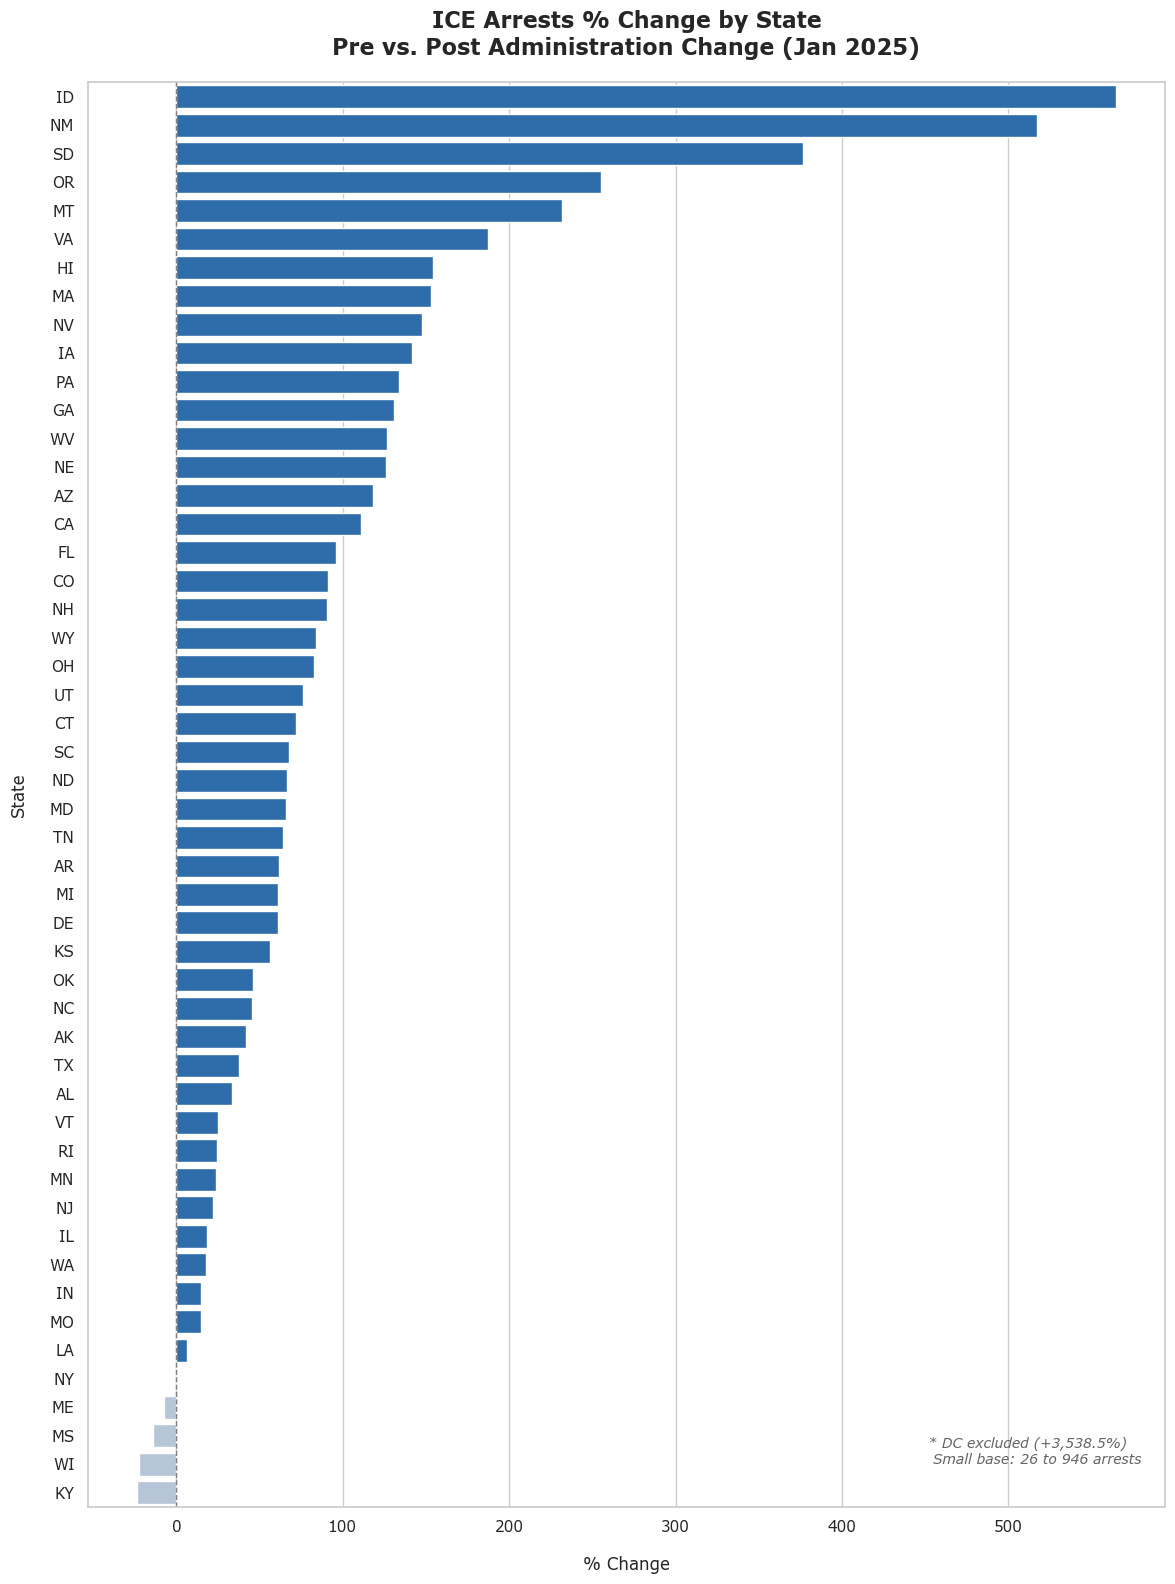

In [24]:
# create a bar chart to show the percentage changes in arrests by state pre/post Trump

# convert state_comparison with numeric values for plotting
state_comparison_plot = arrests_pre_state.merge(
    arrests_post_state,
    on='state',
    suffixes=('_pre', '_post')
)
state_comparison_plot.columns = ['State', 'Pre-Transition', 'Post-Transition']
state_comparison_plot['% Change'] = ((state_comparison_plot['Post-Transition'] - state_comparison_plot['Pre-Transition']) / state_comparison_plot['Pre-Transition'] * 100).round(1)
state_comparison_plot = state_comparison_plot.sort_values('% Change', ascending=False)

# create the chart
state_comparison_plot_filtered = state_comparison_plot[state_comparison_plot['State'] != 'DC']

fig, ax = plt.subplots(figsize=(12, 16))

sns.barplot(
    data=state_comparison_plot_filtered,
    x='% Change',
    y='State',
    palette=['#1A6EBD' if x >= 0 else '#B0C4DE' for x in state_comparison_plot_filtered['% Change']],
    ax=ax
)

ax.axvline(x=0, color='gray', linewidth=1, linestyle='--')
ax.set_title('ICE Arrests % Change by State\nPre vs. Post Administration Change (Jan 2025)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('% Change', labelpad=15)
ax.set_ylabel('State', labelpad=15)

# Note DC separately
ax.annotate('* DC excluded (+3,538.5%)\n Small base: 26 to 946 arrests',
            xy=(0.78, 0.03), xycoords='axes fraction',
            fontsize=10, fontstyle='italic', color='#636363')

plt.tight_layout()
plt.show()

#### age analysis

In [43]:
# count records in various age brackets for the arrests table
print(f'-------ARRESTS-------\n Age Bracket Details')
age_arrests_1_10 = df_arrests[(df_arrests['age'] >= 1) & (df_arrests['age'] <= 10)]
age_percentage_1_10 = len(age_arrests_1_10) / len(df_arrests) * 100
print(f'Arrests ages 1-10: {len(age_arrests_1_10):,}')
print(f'Percentage of total records: {age_percentage_1_10:.2f}%')
print()
age_arrests_11_18 = df_arrests[(df_arrests['age'] >= 11) & (df_arrests['age'] <= 18)]
age_percentage_11_18 = len(age_arrests_11_18) / len(df_arrests) * 100
print(f'Arrests ages 11-18: {len(age_arrests_11_18):,}')
print(f'Percentage of total records: {age_percentage_11_18:.2f}%')
print()
age_arrests_19_30 = df_arrests[(df_arrests['age'] >= 19) & (df_arrests['age'] <= 30)]
age_percentage_19_30 = len(age_arrests_19_30) / len(df_arrests) * 100
print(f'Arrests ages 19-30: {len(age_arrests_19_30):,}')
print(f'Percentage of total records: {age_percentage_19_30:.2f}%')
print()
age_arrests_31_40 = df_arrests[(df_arrests['age'] >= 31) & (df_arrests['age'] <= 40)]
age_percentage_31_40 = len(age_arrests_31_40) / len(df_arrests) * 100
print(f'Arrests ages 31-40: {len(age_arrests_31_40):,}')
print(f'Percentage of total records: {age_percentage_31_40:.2f}%')
print()
age_arrests_41_50 = df_arrests[(df_arrests['age'] >= 41) & (df_arrests['age'] <= 50)]
age_percentage_41_50 = len(age_arrests_41_50) / len(df_arrests) * 100
print(f'Arrests ages 41-50: {len(age_arrests_41_50):,}')
print(f'Percentage of total records: {age_percentage_41_50:.2f}%')
print()
age_arrests_51_60 = df_arrests[(df_arrests['age'] >= 51) & (df_arrests['age'] <= 60)]
age_percentage_51_60 = len(age_arrests_51_60) / len(df_arrests) * 100
print(f'Arrests ages 51-60: {len(age_arrests_51_60):,}')
print(f'Percentage of total records: {age_percentage_51_60:.2f}%')
print()
age_arrests_61_70 = df_arrests[(df_arrests['age'] >= 61) & (df_arrests['age'] <= 70)]
age_percentage_61_70 = len(age_arrests_61_70) / len(df_arrests) * 100
print(f'Arrests ages 61-70: {len(age_arrests_61_70):,}')
print(f'Percentage of total records: {age_percentage_61_70:.2f}%')
print()
age_arrests_71_80 = df_arrests[(df_arrests['age'] >= 71) & (df_arrests['age'] <= 80)]
age_percentage_71_80 = len(age_arrests_71_80) / len(df_arrests) * 100
print(f'Arrests ages 71-80: {len(age_arrests_71_80):,}')
print(f'Percentage of total records: {age_percentage_71_80:.2f}%')
print()
age_arrests_81_90 = df_arrests[(df_arrests['age'] >= 81) & (df_arrests['age'] <= 90)]
age_percentage_81_90 = len(age_arrests_81_90) / len(df_arrests) * 100
print(f'Arrests ages 81-90: {len(age_arrests_81_90):,}')
print(f'Percentage of total records: {age_percentage_81_90:.2f}%')
print()
age_arrests_91_100 = df_arrests[(df_arrests['age'] >= 91) & (df_arrests['age'] <= 100)]
age_percentage_91_100 = len(age_arrests_91_100) / len(df_arrests) * 100
print(f'Arrests ages 91-100: {len(age_arrests_91_100):,}')
print(f'Percentage of total records: {age_percentage_91_100:.2f}%')
print()
age_arrests_over_100 = df_arrests[df_arrests['age'] > 100]
age_percentage_over_100 = len(age_arrests_over_100) / len(df_arrests) * 100
print(f'Arrests ages over 100: {len(age_arrests_over_100):,}')
print(f'Percentage of total records: {age_percentage_over_100:.2f}%')


-------ARRESTS-------
 Age Bracket Details
Arrests ages 1-10: 4,152
Percentage of total records: 1.15%

Arrests ages 11-18: 5,109
Percentage of total records: 1.41%

Arrests ages 19-30: 112,910
Percentage of total records: 31.17%

Arrests ages 31-40: 123,132
Percentage of total records: 34.00%

Arrests ages 41-50: 79,431
Percentage of total records: 21.93%

Arrests ages 51-60: 29,846
Percentage of total records: 8.24%

Arrests ages 61-70: 6,711
Percentage of total records: 1.85%

Arrests ages 71-80: 859
Percentage of total records: 0.24%

Arrests ages 81-90: 49
Percentage of total records: 0.01%

Arrests ages 91-100: 2
Percentage of total records: 0.00%

Arrests ages over 100: 0
Percentage of total records: 0.00%


In [40]:
# doing the same calculations for detainers
print(f'-------DETAINERS-------\n Age Bracket Details')
age_detainers_1_10 = df_detainers[(df_detainers['age'] >= 1) & (df_detainers['age'] <= 10)]
age_percentage_detainers_1_10 = len(age_detainers_1_10) / len(df_detainers) * 100
print(f'Detainers ages 1-10: {len(age_detainers_1_10):,}')
print(f'Percentage of total records: {age_percentage_detainers_1_10:.2f}%')
print()
age_detainers_11_18 = df_detainers[(df_detainers['age'] >= 11) & (df_detainers['age'] <= 18)]
age_percentage_detainers_11_18 = len(age_detainers_11_18) / len(df_detainers) * 100
print(f'Detainers ages 11-18: {len(age_detainers_11_18):,}')
print(f'Percentage of total records: {age_percentage_detainers_11_18:.2f}%')
print()
age_detainers_19_30 = df_detainers[(df_detainers['age'] >= 19) & (df_detainers['age'] <= 30)]
age_percentage_detainers_19_30 = len(age_detainers_19_30) / len(df_detainers) * 100
print(f'Detainers ages 19-30: {len(age_detainers_19_30):,}')
print(f'Percentage of total records: {age_percentage_detainers_19_30:.2f}%')
print()
age_detainers_31_40 = df_detainers[(df_detainers['age'] >= 31) & (df_detainers['age'] <= 40)]
age_percentage_detainers_31_40 = len(age_detainers_31_40) / len(df_detainers) * 100
print(f'Detainers ages 31-40: {len(age_detainers_31_40):,}')
print(f'Percentage of total records: {age_percentage_detainers_31_40:.2f}%')
print()
age_detainers_41_50 = df_detainers[(df_detainers['age'] >= 41) & (df_detainers['age'] <= 50)]
age_percentage_detainers_41_50 = len(age_detainers_41_50) / len(df_detainers) * 100
print(f'Detainers ages 41-50: {len(age_detainers_41_50):,}')
print(f'Percentage of total records: {age_percentage_detainers_41_50:.2f}%')
print()
age_detainers_51_60 = df_detainers[(df_detainers['age'] >= 51) & (df_detainers['age'] <= 60)]
age_percentage_detainers_51_60 = len(age_detainers_51_60) / len(df_detainers) * 100
print(f'Detainers ages 51-60: {len(age_detainers_51_60):,}')
print(f'Percentage of total records: {age_percentage_detainers_51_60:.2f}%')
print()
age_detainers_61_70 = df_detainers[(df_detainers['age'] >= 61) & (df_detainers['age'] <= 70)]
age_percentage_detainers_61_70 = len(age_detainers_61_70) / len(df_detainers) * 100
print(f'Detainers ages 61-70: {len(age_detainers_61_70):,}')
print(f'Percentage of total records: {age_percentage_detainers_61_70:.2f}%')
print()
age_detainers_71_80 = df_detainers[(df_detainers['age'] >= 71) & (df_detainers['age'] <= 80)]
age_percentage_detainers_71_80 = len(age_detainers_71_80) / len(df_detainers) * 100
print(f'Detainers ages 71-80: {len(age_detainers_71_80):,}')
print(f'Percentage of total records: {age_percentage_detainers_71_80:.2f}%')
print()
age_detainers_81_90 = df_detainers[(df_detainers['age'] >= 81) & (df_detainers['age'] <= 90)]
age_percentage_detainers_81_90 = len(age_detainers_81_90) / len(df_detainers) * 100
print(f'Detainers ages 81-90: {len(age_detainers_81_90):,}')
print(f'Percentage of total records: {age_percentage_detainers_81_90:.2f}%')
print()
age_detainers_91_100 = df_detainers[(df_detainers['age'] >= 91) & (df_detainers['age'] <= 100)]
age_percentage_detainers_91_100 = len(age_detainers_91_100) / len(df_detainers) * 100
print(f'Detainers ages 91-100: {len(age_detainers_91_100):,}')
print(f'Percentage of total records: {age_percentage_detainers_91_100:.2f}%')
print()
age_detainers_over_100 = df_detainers[df_detainers['age'] > 100]
age_percentage_detainers_over_100 = len(age_detainers_over_100) / len(df_detainers) * 100
print(f'Detainers ages over 100: {len(age_detainers_over_100):,}')
print(f'Percentage of total records: {age_percentage_detainers_over_100:.2f}%')

-------DETAINERS-------
 Age Bracket Details
Detainers ages 1-10: 2
Percentage of total records: 0.00%

Detainers ages 11-18: 391
Percentage of total records: 0.12%

Detainers ages 19-30: 106,255
Percentage of total records: 32.25%

Detainers ages 31-40: 118,157
Percentage of total records: 35.86%

Detainers ages 41-50: 72,669
Percentage of total records: 22.06%

Detainers ages 51-60: 25,555
Percentage of total records: 7.76%

Detainers ages 61-70: 5,641
Percentage of total records: 1.71%

Detainers ages 71-80: 757
Percentage of total records: 0.23%

Detainers ages 81-90: 41
Percentage of total records: 0.01%

Detainers ages 91-100: 2
Percentage of total records: 0.00%

Detainers ages over 100: 3
Percentage of total records: 0.00%


In [42]:
# doing the same for detentions

# Detentions
print(f'-------DETENTIONS-------\n Age Bracket Details')
age_detentions_1_10 = df_detentions[(df_detentions['age'] >= 1) & (df_detentions['age'] <= 10)]
age_percentage_detentions_1_10 = len(age_detentions_1_10) / len(df_detentions) * 100
print(f'Detentions ages 1-10: {len(age_detentions_1_10):,}')
print(f'Percentage of total records: {age_percentage_detentions_1_10:.2f}%')
print()
age_detentions_11_18 = df_detentions[(df_detentions['age'] >= 11) & (df_detentions['age'] <= 18)]
age_percentage_detentions_11_18 = len(age_detentions_11_18) / len(df_detentions) * 100
print(f'Detentions ages 11-18: {len(age_detentions_11_18):,}')
print(f'Percentage of total records: {age_percentage_detentions_11_18:.2f}%')
print()
age_detentions_19_30 = df_detentions[(df_detentions['age'] >= 19) & (df_detentions['age'] <= 30)]
age_percentage_detentions_19_30 = len(age_detentions_19_30) / len(df_detentions) * 100
print(f'Detentions ages 19-30: {len(age_detentions_19_30):,}')
print(f'Percentage of total records: {age_percentage_detentions_19_30:.2f}%')
print()
age_detentions_31_40 = df_detentions[(df_detentions['age'] >= 31) & (df_detentions['age'] <= 40)]
age_percentage_detentions_31_40 = len(age_detentions_31_40) / len(df_detentions) * 100
print(f'Detentions ages 31-40: {len(age_detentions_31_40):,}')
print(f'Percentage of total records: {age_percentage_detentions_31_40:.2f}%')
print()
age_detentions_41_50 = df_detentions[(df_detentions['age'] >= 41) & (df_detentions['age'] <= 50)]
age_percentage_detentions_41_50 = len(age_detentions_41_50) / len(df_detentions) * 100
print(f'Detentions ages 41-50: {len(age_detentions_41_50):,}')
print(f'Percentage of total records: {age_percentage_detentions_41_50:.2f}%')
print()
age_detentions_51_60 = df_detentions[(df_detentions['age'] >= 51) & (df_detentions['age'] <= 60)]
age_percentage_detentions_51_60 = len(age_detentions_51_60) / len(df_detentions) * 100
print(f'Detentions ages 51-60: {len(age_detentions_51_60):,}')
print(f'Percentage of total records: {age_percentage_detentions_51_60:.2f}%')
print()
age_detentions_61_70 = df_detentions[(df_detentions['age'] >= 61) & (df_detentions['age'] <= 70)]
age_percentage_detentions_61_70 = len(age_detentions_61_70) / len(df_detentions) * 100
print(f'Detentions ages 61-70: {len(age_detentions_61_70):,}')
print(f'Percentage of total records: {age_percentage_detentions_61_70:.2f}%')
print()
age_detentions_71_80 = df_detentions[(df_detentions['age'] >= 71) & (df_detentions['age'] <= 80)]
age_percentage_detentions_71_80 = len(age_detentions_71_80) / len(df_detentions) * 100
print(f'Detentions ages 71-80: {len(age_detentions_71_80):,}')
print(f'Percentage of total records: {age_percentage_detentions_71_80:.2f}%')
print()
age_detentions_81_90 = df_detentions[(df_detentions['age'] >= 81) & (df_detentions['age'] <= 90)]
age_percentage_detentions_81_90 = len(age_detentions_81_90) / len(df_detentions) * 100
print(f'Detentions ages 81-90: {len(age_detentions_81_90):,}')
print(f'Percentage of total records: {age_percentage_detentions_81_90:.2f}%')
print()
age_detentions_91_100 = df_detentions[(df_detentions['age'] >= 91) & (df_detentions['age'] <= 100)]
age_percentage_detentions_91_100 = len(age_detentions_91_100) / len(df_detentions) * 100
print(f'Detentions ages 91-100: {len(age_detentions_91_100):,}')
print(f'Percentage of total records: {age_percentage_detentions_91_100:.2f}%')
print()
age_detentions_over_100 = df_detentions[df_detentions['age'] > 100]
age_percentage_detentions_over_100 = len(age_detentions_over_100) / len(df_detentions) * 100
print(f'Detentions ages over 100: {len(age_detentions_over_100):,}')
print(f'Percentage of total records: {age_percentage_detentions_over_100:.2f}%')


-------DETENTIONS-------
 Age Bracket Details
Detentions ages 1-10: 5,338
Percentage of total records: 0.79%

Detentions ages 11-18: 6,369
Percentage of total records: 0.95%

Detentions ages 19-30: 247,821
Percentage of total records: 36.89%

Detentions ages 31-40: 221,463
Percentage of total records: 32.97%

Detentions ages 41-50: 130,631
Percentage of total records: 19.45%

Detentions ages 51-60: 48,540
Percentage of total records: 7.23%

Detentions ages 61-70: 10,437
Percentage of total records: 1.55%

Detentions ages 71-80: 1,089
Percentage of total records: 0.16%

Detentions ages 81-90: 59
Percentage of total records: 0.01%

Detentions ages 91-100: 3
Percentage of total records: 0.00%

Detentions ages over 100: 0
Percentage of total records: 0.00%


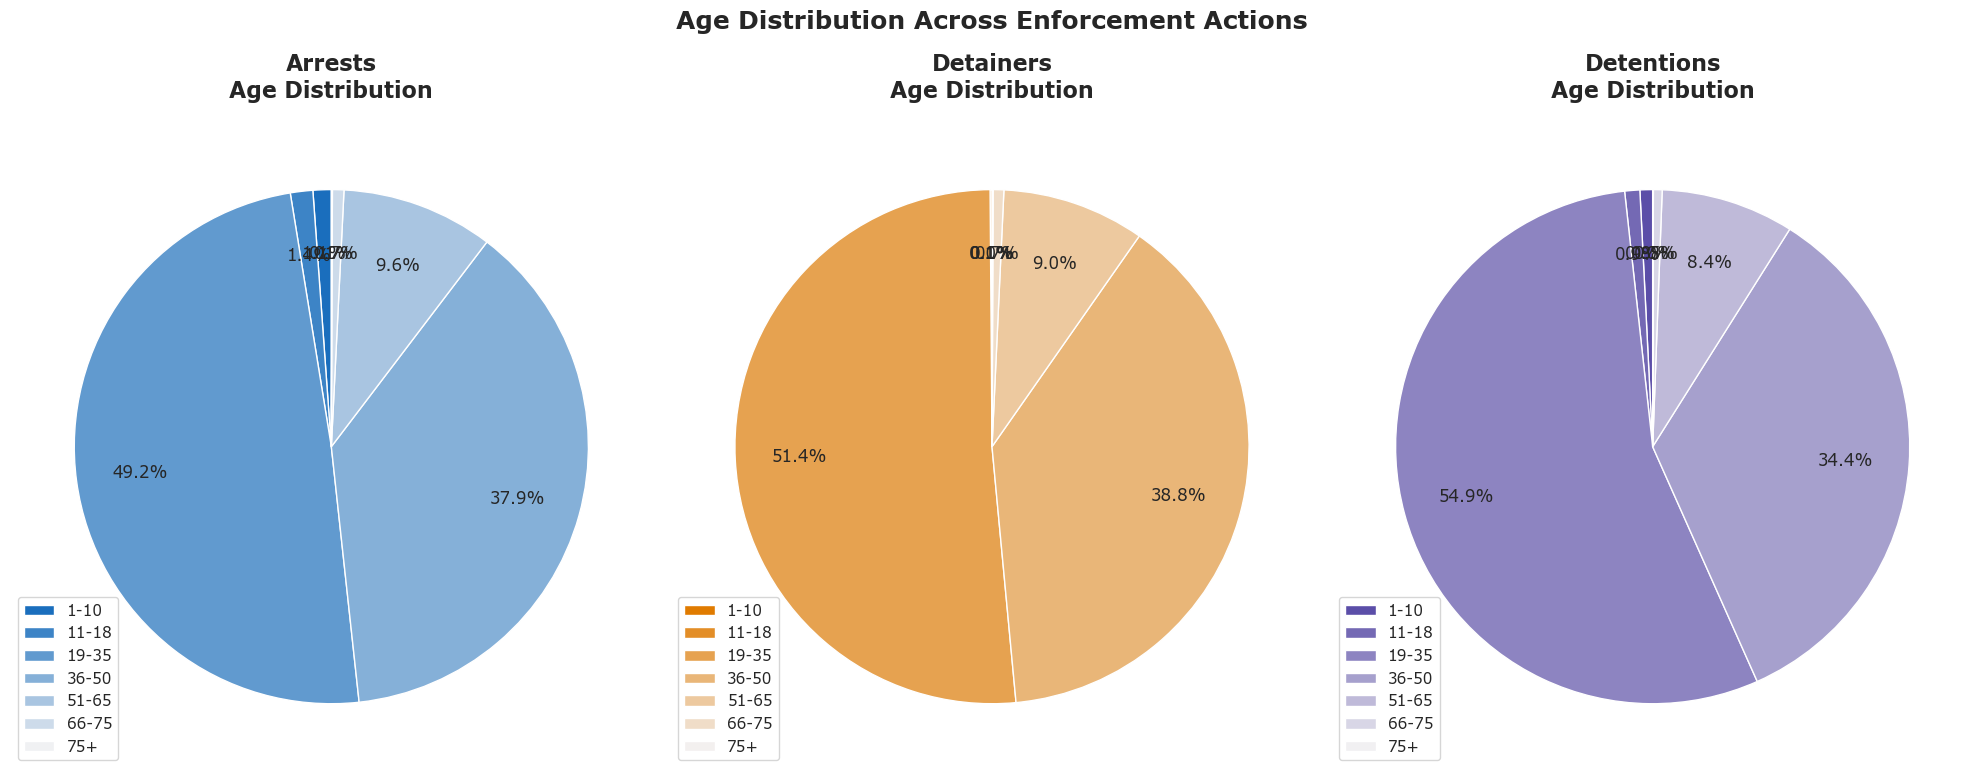

In [50]:
# create a pie chart to demonstrate age brackets

# define age buckets for chart
# Arrests
arrests_pie_1_10 = len(df_arrests[(df_arrests['age'] >= 1) & (df_arrests['age'] <= 10)])
arrests_pie_11_18 = len(df_arrests[(df_arrests['age'] >= 11) & (df_arrests['age'] <= 18)])
arrests_pie_19_35 = len(df_arrests[(df_arrests['age'] >= 19) & (df_arrests['age'] <= 35)])
arrests_pie_36_50 = len(df_arrests[(df_arrests['age'] >= 36) & (df_arrests['age'] <= 50)])
arrests_pie_51_65 = len(df_arrests[(df_arrests['age'] >= 51) & (df_arrests['age'] <= 65)])
arrests_pie_66_75 = len(df_arrests[(df_arrests['age'] >= 66) & (df_arrests['age'] <= 75)])
arrests_pie_75_plus = len(df_arrests[df_arrests['age'] > 75])

# Detainers
detainers_pie_1_10 = len(df_detainers[(df_detainers['age'] >= 1) & (df_detainers['age'] <= 10)])
detainers_pie_11_18 = len(df_detainers[(df_detainers['age'] >= 11) & (df_detainers['age'] <= 18)])
detainers_pie_19_35 = len(df_detainers[(df_detainers['age'] >= 19) & (df_detainers['age'] <= 35)])
detainers_pie_36_50 = len(df_detainers[(df_detainers['age'] >= 36) & (df_detainers['age'] <= 50)])
detainers_pie_51_65 = len(df_detainers[(df_detainers['age'] >= 51) & (df_detainers['age'] <= 65)])
detainers_pie_66_75 = len(df_detainers[(df_detainers['age'] >= 66) & (df_detainers['age'] <= 75)])
detainers_pie_75_plus = len(df_detainers[df_detainers['age'] > 75])

# Detentions
detentions_pie_1_10 = len(df_detentions[(df_detentions['age'] >= 1) & (df_detentions['age'] <= 10)])
detentions_pie_11_18 = len(df_detentions[(df_detentions['age'] >= 11) & (df_detentions['age'] <= 18)])
detentions_pie_19_35 = len(df_detentions[(df_detentions['age'] >= 19) & (df_detentions['age'] <= 35)])
detentions_pie_36_50 = len(df_detentions[(df_detentions['age'] >= 36) & (df_detentions['age'] <= 50)])
detentions_pie_51_65 = len(df_detentions[(df_detentions['age'] >= 51) & (df_detentions['age'] <= 65)])
detentions_pie_66_75 = len(df_detentions[(df_detentions['age'] >= 66) & (df_detentions['age'] <= 75)])
detentions_pie_75_plus = len(df_detentions[df_detentions['age'] > 75])

# create the chart
age_pie_labels: list[str] = ['1-10', '11-18', '19-35', '36-50', '51-65', '66-75', '75+']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 8))

ax1.pie(
    [arrests_pie_1_10, arrests_pie_11_18, arrests_pie_19_35, arrests_pie_36_50, arrests_pie_51_65, arrests_pie_66_75, arrests_pie_75_plus],
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=sns.light_palette('#1A6EBD', n_colors=7, reverse=True),
    startangle=90,
)

ax1.legend(age_pie_labels, loc='lower left')
ax1.set_title('Arrests\nAge Distribution', fontsize=16, fontweight='bold', pad=20)

ax2.pie(
    [detainers_pie_1_10, detainers_pie_11_18, detainers_pie_19_35, detainers_pie_36_50, detainers_pie_51_65, detainers_pie_66_75, detainers_pie_75_plus],
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=sns.light_palette('#E07B00', n_colors=7, reverse=True),
    startangle=90
)

ax2.legend(age_pie_labels, loc='lower left')
ax2.set_title('Detainers\nAge Distribution', fontsize=16, fontweight='bold', pad=20)

ax3.pie(
    [detentions_pie_1_10, detentions_pie_11_18, detentions_pie_19_35, detentions_pie_36_50, detentions_pie_51_65, detentions_pie_66_75, detentions_pie_75_plus],
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=sns.light_palette('#5B4EA8', n_colors=7, reverse=True),
    startangle=90
)

ax3.legend(age_pie_labels, loc='lower left')
ax3.set_title('Detentions\nAge Distribution', fontsize=16, fontweight='bold', pad=20)

plt.suptitle('Age Distribution Across Enforcement Actions', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

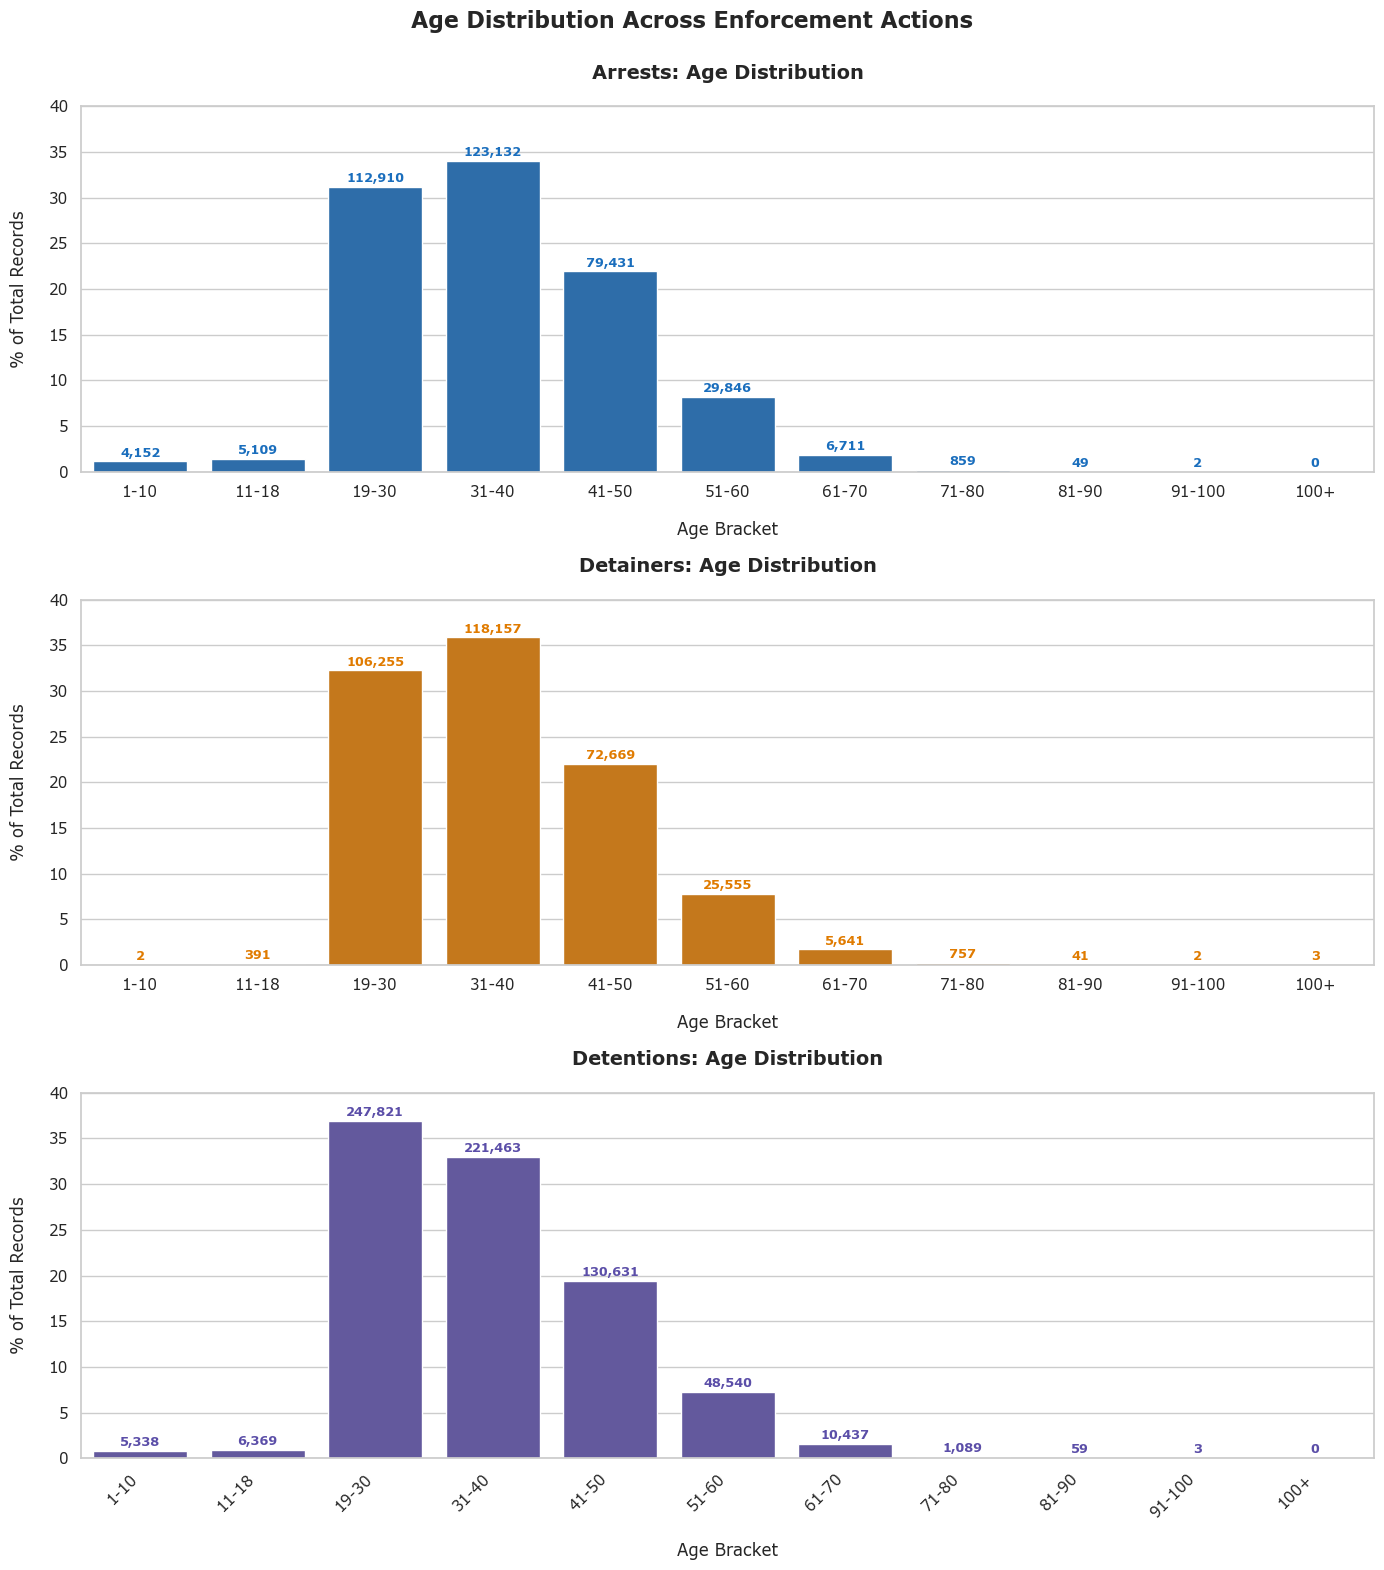

In [58]:
# creating a bar chart instead to better visualize the age distribution
age_bar_labels: list[str] = ['1-10', '11-18', '19-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', '100+']

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 16))

# ARRESTS BAR CHART
sns.barplot(
    x=age_bar_labels,
    y=[
        age_percentage_1_10, age_percentage_11_18, age_percentage_19_30,
        age_percentage_31_40, age_percentage_41_50, age_percentage_51_60,
        age_percentage_61_70, age_percentage_71_80, age_percentage_81_90,
        age_percentage_91_100, age_percentage_over_100
    ],
    color='#1A6EBD',
    ax=ax1
)

# count annotation above bars
age_arrests_heights = [
    age_percentage_1_10, age_percentage_11_18, age_percentage_19_30,
    age_percentage_31_40, age_percentage_41_50, age_percentage_51_60,
    age_percentage_61_70, age_percentage_71_80, age_percentage_81_90,
    age_percentage_91_100, age_percentage_over_100
]
age_arrests_counts = [
    len(age_arrests_1_10), len(age_arrests_11_18), len(age_arrests_19_30),
    len(age_arrests_31_40), len(age_arrests_41_50), len(age_arrests_51_60),
    len(age_arrests_61_70), len(age_arrests_71_80), len(age_arrests_81_90),
    len(age_arrests_91_100), len(age_arrests_over_100)
]
for x, height, count in zip(range(11), age_arrests_heights, age_arrests_counts):
    ax1.text(x, height + 0.3, f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1A6EBD')

ax1.set_title('Arrests: Age Distribution', fontsize=14, fontweight='semibold', pad=20)
ax1.set_xlabel('Age Bracket', labelpad=15)
ax1.set_ylabel('% of Total Records', labelpad=15)
ax1.set_ylim(0, 40)
plt.xticks(rotation=45, ha='right')

# DETAINERS BAR CHART
sns.barplot(
    x=age_bar_labels,
    y=[
        age_percentage_detainers_1_10, age_percentage_detainers_11_18, age_percentage_detainers_19_30,
        age_percentage_detainers_31_40, age_percentage_detainers_41_50, age_percentage_detainers_51_60,
        age_percentage_detainers_61_70, age_percentage_detainers_71_80, age_percentage_detainers_81_90,
        age_percentage_detainers_91_100, age_percentage_detainers_over_100
    ],
    color='#E07B00',
    ax=ax2
)

age_detainer_heights = [
    age_percentage_detainers_1_10, age_percentage_detainers_11_18, age_percentage_detainers_19_30,
    age_percentage_detainers_31_40, age_percentage_detainers_41_50, age_percentage_detainers_51_60,
    age_percentage_detainers_61_70, age_percentage_detainers_71_80, age_percentage_detainers_81_90,
    age_percentage_detainers_91_100, age_percentage_detainers_over_100
]
age_detainer_counts = [
    len(age_detainers_1_10), len(age_detainers_11_18), len(age_detainers_19_30),
    len(age_detainers_31_40), len(age_detainers_41_50), len(age_detainers_51_60),
    len(age_detainers_61_70), len(age_detainers_71_80), len(age_detainers_81_90),
    len(age_detainers_91_100), len(age_detainers_over_100)
]
for x, height, count in zip(range(11), age_detainer_heights, age_detainer_counts):
    ax2.text(x, height + 0.3, f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#E07B00')

ax2.set_title('Detainers: Age Distribution', fontsize=14, fontweight='semibold', pad=20)
ax2.set_xlabel('Age Bracket', labelpad=15)
ax2.set_ylabel('% of Total Records', labelpad=15)
ax2.set_ylim(0, 40)
plt.xticks(rotation=45, ha='right')

# DETENTIONS BAR CHART
sns.barplot(
    x=age_bar_labels,
    y=[
        age_percentage_detentions_1_10, age_percentage_detentions_11_18, age_percentage_detentions_19_30,
        age_percentage_detentions_31_40, age_percentage_detentions_41_50, age_percentage_detentions_51_60,
        age_percentage_detentions_61_70, age_percentage_detentions_71_80, age_percentage_detentions_81_90,
        age_percentage_detentions_91_100, age_percentage_detentions_over_100
    ],
    color='#5B4EA8',
    ax=ax3
)

age_detention_heights = [
    age_percentage_detentions_1_10, age_percentage_detentions_11_18, age_percentage_detentions_19_30,
    age_percentage_detentions_31_40, age_percentage_detentions_41_50, age_percentage_detentions_51_60,
    age_percentage_detentions_61_70, age_percentage_detentions_71_80, age_percentage_detentions_81_90,
    age_percentage_detentions_91_100, age_percentage_detentions_over_100
]
age_detention_counts = [
    len(age_detentions_1_10), len(age_detentions_11_18), len(age_detentions_19_30),
    len(age_detentions_31_40), len(age_detentions_41_50), len(age_detentions_51_60),
    len(age_detentions_61_70), len(age_detentions_71_80), len(age_detentions_81_90),
    len(age_detentions_91_100), len(age_detentions_over_100)
]
for x, height, count in zip(range(11), age_detention_heights, age_detention_counts):
    ax3.text(x, height + 0.3, f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#5B4EA8')

ax3.set_title('Detentions: Age Distribution', fontsize=14, fontweight='semibold', pad=20)
ax3.set_xlabel('Age Bracket', labelpad=15)
ax3.set_ylabel('% of Total Records', labelpad=15)
ax3.set_ylim(0, 40)
plt.xticks(rotation=45, ha='right')

plt.suptitle('Age Distribution Across Enforcement Actions\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### gender analysis

In [59]:
# check gender and age values

print('--- Gender Values ---')
print('Arrests:', df_arrests['gender'].unique())
print('Detainers:', df_detainers['gender'].unique())
print('Detentions:', df_detentions['gender'].unique())

print('\n--- Age Range ---')
print('Arrests:', df_arrests['age'].min(), '->', df_arrests['age'].max())
print('Detainers', df_detainers['age'].min(), '->', df_detainers['age'].max())
print('Detentions', df_detentions['age'].min(), '->', df_detentions['age'].max())

--- Gender Values ---
Arrests: <ArrowStringArray>
['MALE', 'FEMALE', 'UNKNOWN']
Length: 3, dtype: str
Detainers: <ArrowStringArray>
['FEMALE', 'MALE', 'UNKNOWN']
Length: 3, dtype: str
Detentions: <ArrowStringArray>
['MALE', 'FEMALE', 'UNKNOWN']
Length: 3, dtype: str

--- Age Range ---
Arrests: 1 -> 94
Detainers 1 -> 115
Detentions 1 -> 96


### data integrity concern analysis

In [26]:
# MSC SENTENCE ANALYSIS
df_detainers['msc_sentence_days_total'].describe().round(0)


count     78215.0
mean       1184.0
std        3923.0
min           1.0
25%          75.0
50%         365.0
75%        1126.0
max      364635.0
Name: msc_sentence_days_total, dtype: float64

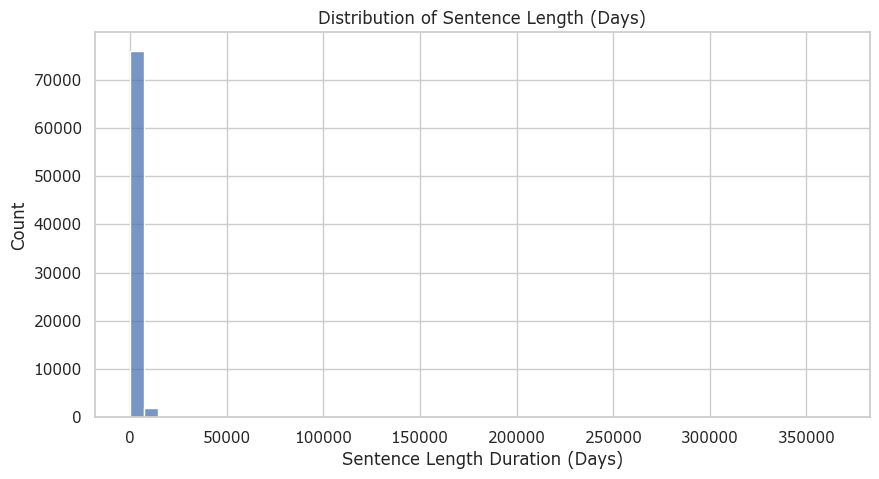

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_detainers,
    x='msc_sentence_days_total',
    bins=50,
    ax=ax
)

ax.set_title('Distribution of Sentence Length (Days)')
ax.set_xlabel('Sentence Length Duration (Days)')
ax.set_ylabel('Count')

plt.tight_layout
plt.show()

# the plot that is returned is skewed heavily by the massively long sentences in the data

In [28]:
# Defining a new category/column to flag virtual life sentences per The Sentencing Project's definition
# www.sentencingproject.org

virtual_life_days: int = 18250 # 50 years x 365 days

df_detainers['virtual_life_sentence'] = (df_detainers['msc_sentence_days_total'] >= virtual_life_days)

total_sentenced: int = df_detainers['msc_sentence_days_total'].notna().sum()
virtual_life_count: int = df_detainers['virtual_life_sentence'].sum()

print(f'Total records with sentence data:    {total_sentenced}')
print(f'Virtual life sentences flagged:    {virtual_life_count:,}')
print(f'Percentage of sentenced records:    {virtual_life_count / total_sentenced * 100:.2f}%')

Total records with sentence data:    78215
Virtual life sentences flagged:    183
Percentage of sentenced records:    0.23%


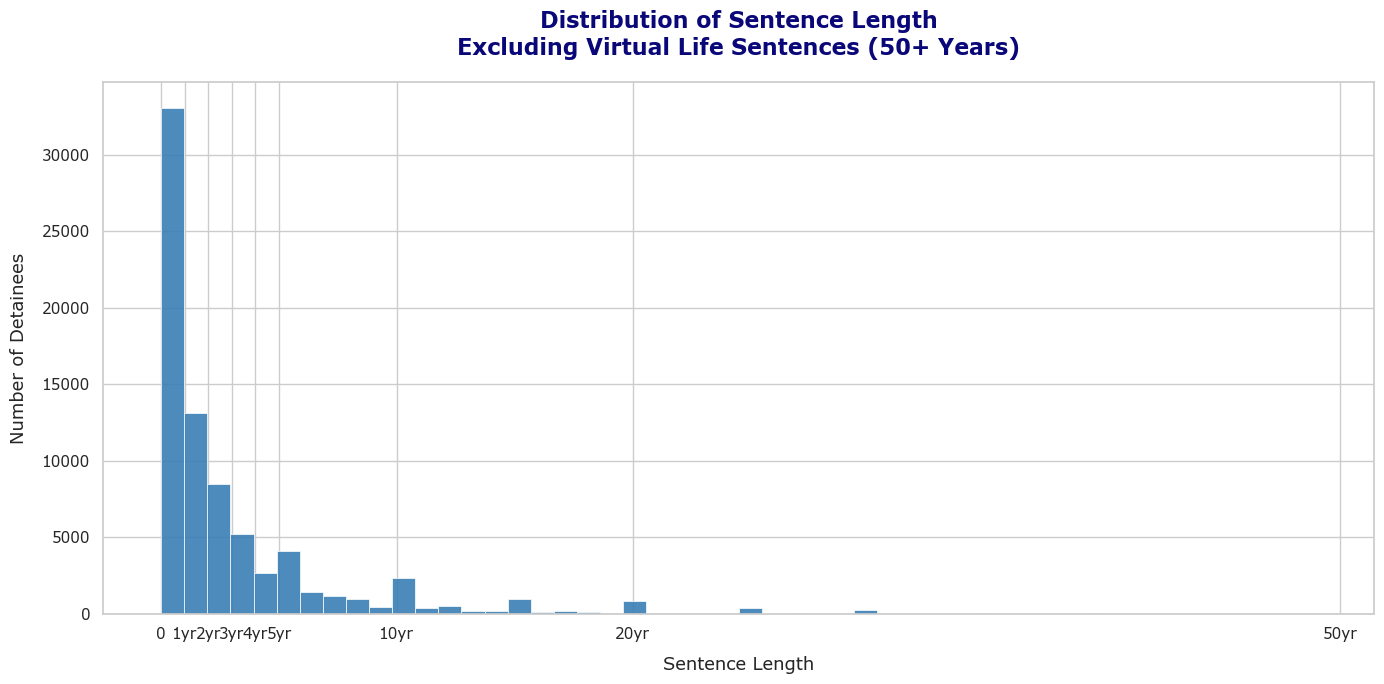

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))

plot_data = df_detainers[df_detainers['virtual_life_sentence'] == False]

sns.histplot(
    data=plot_data,
    x='msc_sentence_days_total',
    bins=50,
    ax=ax,
    color='#3a7eb6',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.9
)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.set_title(
    'Distribution of Sentence Length\nExcluding Virtual Life Sentences (50+ Years)',
    fontsize=16,
    fontweight='bold',
    pad=20,
    color='#0a0879'
)
ax.set_xlabel('Sentence Length', fontsize=13, labelpad=10)
ax.set_ylabel('Number of Detainees', fontsize=13, labelpad=10)

ax.set_xticks([0, 365, 730, 1095, 1460, 1825, 3650, 7300, 18250])
ax.set_xticklabels(
    ['0', '1yr', '2yr', '3yr', '4yr', '5yr', '10yr', '20yr', '50yr'],
    fontsize=11
)

plt.tight_layout()
plt.show()